# Additional Pipeline Syntaxes

This notebooks introduces some new syntaxes to ease creation and manipulation of `Pipeline`objects:

- named pipelines,
- combination using `|` operation,
- reversing pipelines.

In [1]:
import numpy as np

def repr_ndarray(arr):
    return f"array(..., shape={arr.shape}, dtype={arr.dtype})"

np.set_printoptions(override_repr=repr_ndarray)

In [2]:
import pyearthtools.data
import pyearthtools.pipeline

To illustrate these features, we'll reuse the same pipeline as the one used in the [End-to-end CNN Training Example](../tutorial/CNN-Model-Training.ipynb).
Here is the original definition of the pipeline.

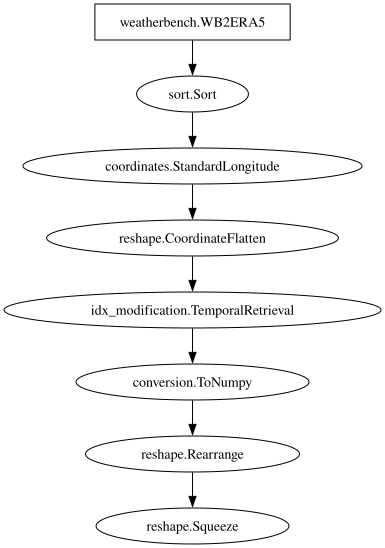

In [3]:
pyearthtools.pipeline.Pipeline(
    pyearthtools.data.download.weatherbench.WB2ERA5(
        variables=["2m_temperature", "u", "v", "geopotential", "vorticity"],
        level=[850],
        license_ok=True,
    ),
    pyearthtools.pipeline.operations.xarray.Sort(
        ["2m_temperature", "u_component_of_wind", "v_component_of_wind", "vorticity", "geopotential"]
    ),
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="0-360"),
    pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((0, 1), (6, 1))
    ),
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange("c t h w -> t c h w"),
    pyearthtools.pipeline.operations.numpy.reshape.Squeeze(axis=0),
)

## Named pipelines

When developing a new pipeline, it can be convenient to separate the main stages of a long pipeline into these sub-pipelines, and assemble them into one big pipeline afterwards.
However, once the pipeline has been assembled, we loose access to the sub-pipelines.
To solve this, we can add a **name** to each of the sub-pipelines.
Then, in the final pipeline, we can recover them via the `.named` attribute, which is a dictionary of all the named sub-pipelines contained in a pipeline.

In the following example, we build the same pipeline but split into 3 stages:
- a named pipeline "prepare", to fetch the data and apply few transformation on it,
- a temporal retrieval step, to generate the tuple of (features, target) samples,
- a named pipeline "reshape", to do the final convertion to numpy and reshaping.

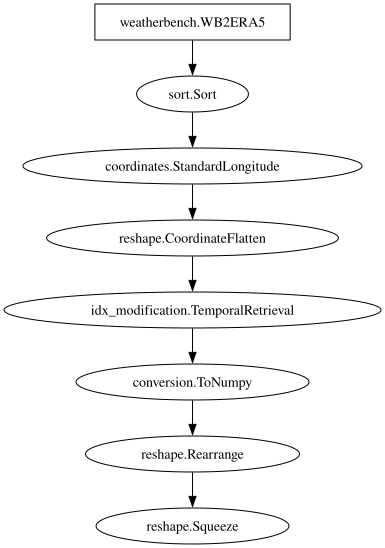

In [4]:
pipeline = pyearthtools.pipeline.Pipeline(
    pyearthtools.pipeline.Pipeline(
        pyearthtools.data.download.weatherbench.WB2ERA5(
            variables=["2m_temperature", "u", "v", "geopotential", "vorticity"],
            level=[850],
            license_ok=True,
        ),
        pyearthtools.pipeline.operations.xarray.Sort(
            ["2m_temperature", "u_component_of_wind", "v_component_of_wind", "vorticity", "geopotential"]
        ),
        pyearthtools.data.transforms.coordinates.StandardLongitude(type="0-360"),
        pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),
        name="prepare"
    ),
    pyearthtools.pipeline.modifications.TemporalRetrieval(concat=True, samples=((0, 1), (6, 1))),
    pyearthtools.pipeline.Pipeline(
        pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
        pyearthtools.pipeline.operations.numpy.reshape.Rearrange("c t h w -> t c h w"),
        pyearthtools.pipeline.operations.numpy.reshape.Squeeze(axis=0),
        name="reshape"
    ),
)
pipeline

We can inspect the `.named` attribute to see which named pipelines are accessible within a pipeline.

In [5]:
pipeline.named.keys()

dict_keys(['prepare', 'reshape'])

Then we can access the named pipeline "prepare" as follows.

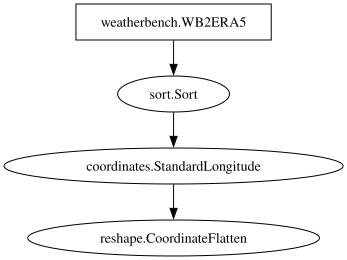

In [6]:
pipeline.named["prepare"]

And even use it without the rest of the pipeline, as it includes a data source.

In [7]:
pipeline.named["prepare"]["20210101T00"]

<xarray.Dataset> Size: 42kB
Dimensions:                 (latitude: 32, longitude: 64, time: 1)
Coordinates:
  * latitude                (latitude) float64 256B -87.19 -81.56 ... 87.19
  * longitude               (longitude) float64 512B 0.0 5.625 ... 348.8 354.4
  * time                    (time) datetime64[ns] 8B 2021-01-01
Data variables:
    2m_temperature          (time, longitude, latitude) float32 8kB dask.array<chunksize=(1, 64, 32), meta=np.ndarray>
    u_component_of_wind850  (time, longitude, latitude) float32 8kB dask.array<chunksize=(1, 64, 32), meta=np.ndarray>
    v_component_of_wind850  (time, longitude, latitude) float32 8kB dask.array<chunksize=(1, 64, 32), meta=np.ndarray>
    vorticity850            (time, longitude, latitude) float32 8kB dask.array<chunksize=(1, 64, 32), meta=np.ndarray>
    geopotential850         (time, longitude, latitude) float32 8kB dask.array<chunksize=(1, 64, 32), meta=np.ndarray>
Attributes:
    level-dtype:  int64

## Pipe operator

The `Pipeline` object also support the `|` operator (logical or) as a way to combine multiple pipelines together.
This has the same effect as creating a new `Pipeline` object as a combination of 2 pipelines (or a pipeline and a step).
This has not additional effect and can be used to increase the readability when building a long pipeline.

In the following example, we now create the sub-pipelines and the temporal retrieval step separately, as distinct objects, then combine them using the `|` operator.

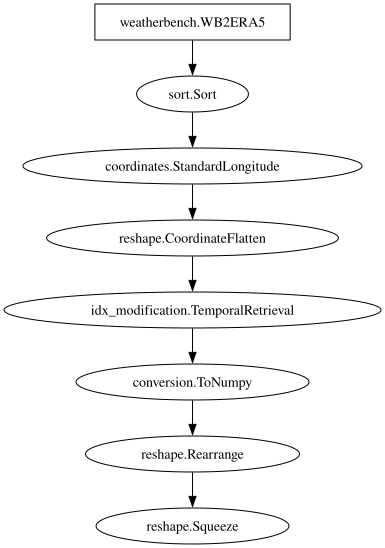

In [8]:
prepare = pyearthtools.pipeline.Pipeline(
    pyearthtools.data.download.weatherbench.WB2ERA5(
        variables=["2m_temperature", "u", "v", "geopotential", "vorticity"],
        level=[850],
        license_ok=True,
    ),
    pyearthtools.pipeline.operations.xarray.Sort(
        ["2m_temperature", "u_component_of_wind", "v_component_of_wind", "vorticity", "geopotential"]
    ),
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="0-360"),
    pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),
    name="prepare"
)

retrieve = pyearthtools.pipeline.modifications.TemporalRetrieval(concat=True, samples=((0, 1), (6, 1)))

reshape = pyearthtools.pipeline.Pipeline(
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange("c t h w -> t c h w"),
    pyearthtools.pipeline.operations.numpy.reshape.Squeeze(axis=0),
    name="reshape"
)

pipeline = prepare | retrieve | reshape
pipeline

In [9]:
pipeline["20210101T00"]

(array(..., shape=(5, 64, 32), dtype=float32),
 array(..., shape=(5, 64, 32), dtype=float32))

## Reversed pipeline

Some pipeline can be reversed, i.e. undoing their effect.
This is only possible if all steps of a pipeline can be *transposed*, via their `.T` attribute.
The reverse of a pipeline, if feasible, can be obtained via the `.reversed` atttribute.

In the following example, we'll reverse the "reshape" sub-pipeline, which is only made of reversible steps.

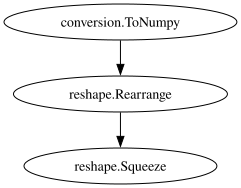

In [10]:
pipeline.named["reshape"]

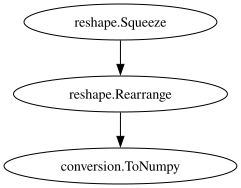

In [11]:
pipeline.named["reshape"].reversed

To test it, we'll fetch a sample from the "prepare" pipeline, reshape it and apply the reverse.

In [12]:
# FIXME
(prepare | reshape | reshape.reversed)["20210101T00"]

RuntimeError: Data hasn't been converted to arrays with this. So data cannot be undone